<a href="https://colab.research.google.com/github/taehi5/Esaa_YB/blob/5%EC%A3%BC%EC%B0%A8-%EA%B3%BC%EC%A0%9C/ESAA_YB_Week5_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

`파이썬 머신러닝 완벽가이드 ch3. 1~7 pg.145~180`


# 평가

✅ 머신러닝 프로세스 : 데이터 가공/변환  ➡ 모델 학습/예측 ➡ 평가

✅ 성능 평가 지표: 모델이 분류나 회귀냐에 따라서 여러 종류로 나뉨
- 회귀: 실제값과 예측값의 오차 평균값에 기반
- 분류 : 실제 결과 데이터와 예측 결과 데이터가 얼마나 정확하고 오류가 적게 발생하는지에 기반


✅ 분류 성능 평가 지표
1. 정확도
2. 오차 행렬
3. 정밀도
4. 재현율
5. F1 스코어
6. ROC AUC <br>
▶ 이진/멀티 둘 다 되지만 이진 분류에서 주로 사용됨

## 정확도

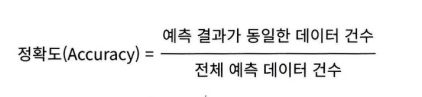

모델 예측 성능을 나타내는 평가지표

❗ 데이터의 구성에 따라 모델 성능 왜곡 가능  -> 예제로 확인

✅ 타이타닉 데이터
- 한 가지 의문점: 성별 조건 하나만을 가지고 결정하는 알고리즘도 높은 정확도가 발생


➡ 사이킷런의 BaseEstimator 클래스를 상속받아 학습 없이 성별로 생존자를 예측하는 단순한 Classifier 생성

In [ ]:
# 미리 실행하는 코드
from sklearn.preprocessing import LabelEncoder

def fillna(df):
    df = df.copy()
    df['Age'] = df['Age'].fillna(df['Age'].mean())
    df['Cabin'] = df['Cabin'].fillna('N')
    df['Embarked'] = df['Embarked'].fillna('N')
    df['Fare'] = df['Fare'].fillna(0)
    return df

def drop_features(df):
    return df.drop(['PassengerId', 'Name', 'Ticket'], axis=1)

def format_features(df):
    df['Cabin'] = df['Cabin'].str[:1]
    for feature in ['Cabin', 'Sex', 'Embarked']:
        le = LabelEncoder()
        df[feature] = le.fit_transform(df[feature])
    return df

def transform_features(df):
    df = fillna(df)
    df = drop_features(df)
    df = format_features(df)
    return df

In [ ]:
from sklearn.base import BaseEstimator

class MyDummyClassifier(BaseEstimator):
  # fit()는 아무것도 학습하지 않음
  def fit(self,X,y=None):
    pass
  # predict()는 단순히 sex피처가 1이면 0, 그렇지 않으면 1로 예측
  def predict(self,X):
    pred = np.zeros((X.shape[0],1))
    for i in range(X.shape[0]):
      if X['Sex'].iloc[i] == 1:
        pred[i] = 0
      else:
        pred[i] = 1
    return pred

MyDummyClassifier를 이용해 생존자 예측 수행

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 원본 데이터를 재로딩 , 데이터 가공, 학습 데이터/테스트 데이터 분할
titanic_df = pd.read_csv('/content/train.csv')
y_titanic_df = titanic_df['Survived']
X_titanic_df = titanic_df.drop('Survived', axis=1)
X_titanic_df = transform_features(X_titanic_df)
X_train, X_test, y_train, y_test = train_test_split(X_titanic_df, y_titanic_df, test_size=0.2, random_state=0)

# 위에서 생성한 Dummy Classifier를 이용해 학습/예측 평가 수행
myclf = MyDummyClassifier()
myclf.fit(X_train, y_train)

mypredictions = myclf.predict(X_test)
print('Dummy Classifier의 정확도는: {0:.4f}'.format(accuracy_score(y_test, mypredictions)))


Dummy Classifier의 정확도는: 0.7877


❗ 불균형한 레이블 값 분포에서 ML 모델의  성능을 판단할 경우, 적합한 평가 지표가 아님

✅ MNIST 데이터
<br> 불균형한 데이터 세트로 만든 후 문제 확인
- MNIST : 0부터 9까지의 숫자 이미지의 픽셀 정보를 가지고 있으며 이를 기반으로 숫자 DIgit을 예측하는 데 사용


➡ 레이블 값이 7인 것만 T, 나머지는 모두 F로 변환

In [ ]:
from string import digits
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

class MyFakeClassifier(BaseEstimator):
  def fit(self,X,y):
    pass

  # 입력값으로 들어오는 X 데이터 세트의 크기만큼 모두 0값으로 만들어서 반환
  def predict(self,X):
    return np.zeros((len(X),1), dtype=bool)


# 사이킷런의 내장 데이터 세트인 load_digits()를 이용해 MNIST 데이터 로딩
digits = load_digits()

# digits 번호가 7이면 T이고 이를 astype(int)로 1로 변환, 7번이 아니면 F이고 0으로 변환
y= (digits.target == 7).astype(int)
X_train, X_test, y_train, y_test = train_test_split(digits.data, y, random_state=11)

In [ ]:
# 불균형한 레이블 데이터 분포도 확인
print('레이블 테스트 세트 크기:',y_test.shape)
print('테스트 세트 레이블 0과 1의 분포도')
print(pd.Series(y_test).value_counts())

#Dummy Classifier로 학습/예측/정확도 평가
fakeclf = MyFakeClassifier()
fakeclf.fit(X_train, y_train)
fakepred = fakeclf.predict(X_test)
print('모든 예측을 0으로 하여도 정확도는:{:.3f}'.format(accuracy_score(y_test, fakepred)))

레이블 테스트 세트 크기: (450,)
테스트 세트 레이블 0과 1의 분포도
0    405
1     45
Name: count, dtype: int64
모든 예측을 0으로 하여도 정확도는:0.900


단지 모든 것을 0으로만 예측해도 정확도가 90%임

➡ 정확도 평가 지표는 불균형한 레이블 데이터 세트에서는 성능 수치로 사용되어서는 안됨

## 오차 행렬


이진 분류의 예측 오류가 얼마인지와 더불어 어떠한 유형의 예측 오류가 발생하고 있는지를 함께 나타내는 지표

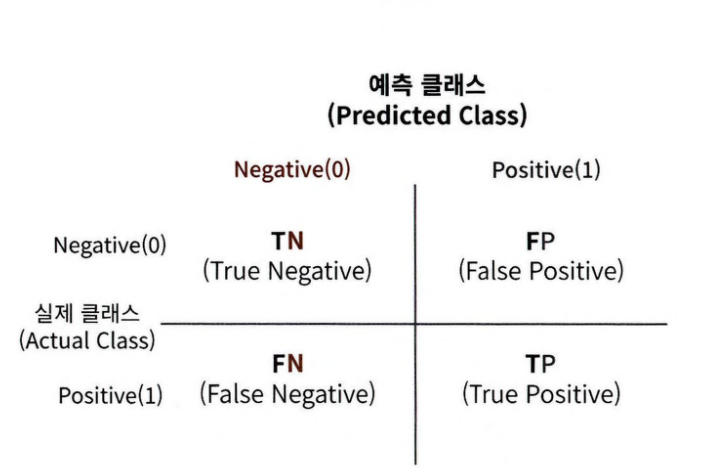

- TP: 예측값을 N = 0 으로 예측했고 실제 값도 N = 0
- FP: 예측값을 P = 1로 예측했는데 실제 값은 N = 0
- FN: 예측값을 N = 0으로 예측했는데 실제 값은 P = 1
- TP: 예측값을 P = 1로 예측했고 실제 값도 P = 1

사이킷런 : `confusion_matrix` API 제공

In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, fakepred)

array([[405,   0],
       [ 45,   0]])

- ndarray 형태



✅ TP,TN,FP,TN은 여러 정보를 제공
 - **정확도 = 예측 결과와 실제 값이 동일한 건수 / 전체 데이터 수 = (TN+TP)/(TN+FP+FN+TP)**

✅ 불균형 레이블 클래스를 가지는 이진 분류 모델
- 많은 데이터 중에서 중점적으로 찾아야 하는 적은 수의 결괏값에 P=1 부여, 나머지는 N=0부여
- P가 매우 적기 때문에 N으로 예측 정확도가 높아지는 경향 발생

❗정확도는 분류 모델 성능 측정이 가능한 한 가지 요소일 뿐 모델 항상 믿으면 ❌

## 정밀도와 재현율

**정밀도 = TP/(FP+TP)**
<br> **재현율 = TP/(FN+TP)**

✅ 정밀도  : 예측을 P로 한 대상 중 예측과 실제 값이 P로 일치한 데이터의 비율
 - P 예측 성능을 더욱 정밀하게 측정하기 위한 평가 지표
 - 양성 예측도
 - *실제 N음성 데이터 예측을 P양성으로 잘못 판단하게 되면 업무상 큰 영향이 발생하는 경우*에 주로 사용
 - FP를 낮추는 데 초점


✅ 재현율 : 실제 값이 P인 대상 중 예측과 실제 값이 P로 일치한 데이터의 비율
- 민감도 / TPR
- *실제 P양성 데이터를 N으로 잘못 판단하게 되면 업무상 큰 영향이 발생하는 경우*에 주로 사용
- 보통 재현율이 정밀도보다 상대적으로 중요한 업무가 많음
- FN을 낮추는 데 초점


➡ 재현율과 정밀도는 서로 보완적인 지표로 분류의 성능을 평가하는데 적용





In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

def get_clf_eval(y_test, pred):
  confusion = confusion_matrix(y_test, pred)
  accuracy = accuracy_score(y_test, pred)
  precision = precision_score(y_test, pred)
  recall = recall_score(y_test, pred)
  print('오차 행렬')
  print(confusion)
  print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}'.format(accuracy, precision, recall))


로지스틱 회귀 기반으로 타이타닉 생존자를 예측

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# 데이터 불러오기: Colab에 업로드한 파일명에 맞추세요.
titanic_df = pd.read_csv('/content/train.csv')

# 정답과 입력 데이터 분리
y_titanic_df = titanic_df['Survived']
X_titanic_df = titanic_df.drop('Survived', axis=1)

# 입력 데이터 전처리
X_titanic_df = transform_features(X_titanic_df)

# 학습 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X_titanic_df,
    y_titanic_df,
    test_size=0.2,
    random_state=11
)

# 모델 학습
lr_clf = LogisticRegression(solver='liblinear')
lr_clf.fit(X_train, y_train)

# 예측 및 평가
pred = lr_clf.predict(X_test)
get_clf_eval(y_test, pred)


오차 행렬
[[108  10]
 [ 14  47]]
정확도: 0.8659, 정밀도: 0.8246, 재현율: 0.7705


### 정밀도/재현율 트레이드오프

정밀도와 재현율은 상호 보완적인 평가 지표이기 때문에 어느 한 쪽을 강제로 높이면 다른 하나의 수치는 떨어지기 쉽다.

1. 개별 레이블 별 결정 확률 구함
2. 예측 확률이 큰 레이블 값으로 예측하게 됨
▶ 일반적으로 이진 분류에서는 임곗값을 0.5로 설정, 확률이 크면 P, 작으면 N

✅사이킷 런의 predict_proba()
- 학습 완료된 사이킷런 classifier 객체에서 호출 가능
- 테스트 피처 레코드의 개별 클래스  예측 확률 반환


✅타이타닉 생존자 data에서 확인

In [27]:
pred_proba = lr_clf.predict_proba(X_test)
pred = lr_clf.predict(X_test)
print('pred_proba()결과 Shape : {0}'.format(pred_proba.shape))
print('pred_proba array에서 앞 3개만 샘플로 추출 \n:', pred_proba[:3])

#예측 확률 array와 예측 결괏값 array를 병합해 예측 확률과 결괏값을 한눈에 확인
pred_proba_result = np.concatenate([pred_proba, pred.reshape(-1,1)], axis=1)
print('두 개의 class 중에서 더 큰 확률을 클래스 값으로 예측 \n', pred_proba_result[:3])

pred_proba()결과 Shape : (179, 2)
pred_proba array에서 앞 3개만 샘플로 추출 
: [[0.44935227 0.55064773]
 [0.86335512 0.13664488]
 [0.86429645 0.13570355]]
두 개의 class 중에서 더 큰 확률을 클래스 값으로 예측 
 [[0.44935227 0.55064773 1.        ]
 [0.86335512 0.13664488 0.        ]
 [0.86429645 0.13570355 0.        ]]


➡ 두 개의 컬럼 중에서 더 큰 확률 값으로 predict()메서드가 최종 예측

✅predict()메서드
- predict_proba() 메서드에 기반해 생성된 API
- predict_proba() 호출 결과로 반환된 배열에서 분류 결정 임곗값보다 큰 값이 들어있는 칼럼의 위치 반환 후 최종적으로 예측 클래스를 결정하는 API

✅사이킷런의 정밀도/재현율 트레이드 오프 방식 코드 구현

In [28]:
from sklearn.preprocessing import Binarizer

X = [[1,-1,2],
     [2,0,0],
     [0,1.1,1.2]]

# X의  개별 원소들이 threshold값보다 같거나 작으면 0을, 크면 1을 반환
binarizer = Binarizer(threshold=1.1)
print(binarizer.fit_transform(X))

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]]


In [29]:
from sklearn.preprocessing import Binarizer

# Binarizer의 threshlod 설정값, 분류 결정 임곗값임.
custom_thresholdr = 0.5

# predic_proba() 반환값의 두번째 칼럼, 즉 Positive 클래스 칼럼 하나만 추출해 Binarizer를 적용
pred_proba_1 = pred_proba[:,1].reshape(-1,1)

binarizer = Binarizer(threshold=custom_thresholdr).fit(pred_proba_1)
custom_predict = binarizer.transform(pred_proba_1)

get_clf_eval(y_test, custom_predict)

오차 행렬
[[108  10]
 [ 14  47]]
정확도: 0.8659, 정밀도: 0.8246, 재현율: 0.7705


In [30]:
# Binarizer의 threshold 설정값을 0.4로 설정, 즉 분류 결정 임곗값을 0.5에서 0.4로 낮춤
custom_threshold = 0.4
pred_proba_1 = pred_proba[:,1].reshape(-1,1)
binarizer = Binarizer(threshold=custom_threshold).fit(pred_proba_1)
custom_predict = binarizer.transform(pred_proba_1)

get_clf_eval(y_test, custom_predict)

오차 행렬
[[97 21]
 [11 50]]
정확도: 0.8212, 정밀도: 0.7042, 재현율: 0.8197


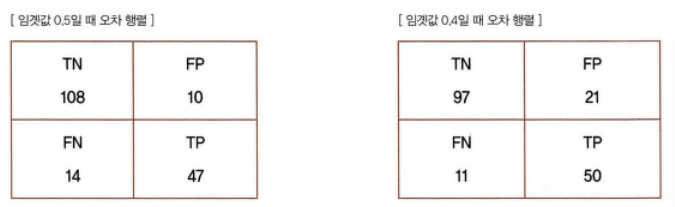

In [31]:
# 테스트를 수행할 모든 임곗값을 리스크 객체로 저장
thresholds = [0.4,0.45,0.50,0.55,0.60]

def get_eval_by_threshold(y_test, pred_proba_c1,thresholds):
  # thresholds list 객체 내의 값을 차례로 iteration하면서 Evaluation 수행
  for custom_threshold in thresholds:
    binarizer = Binarizer(threshold=custom_threshold).fit(pred_proba_c1)
    custom_predict = binarizer.transform(pred_proba_c1)
    print('임곗값:',custom_threshold)
    get_clf_eval(y_test, custom_predict)

get_eval_by_threshold(y_test,pred_proba[:,1].reshape(-1,1),thresholds)

임곗값: 0.4
오차 행렬
[[97 21]
 [11 50]]
정확도: 0.8212, 정밀도: 0.7042, 재현율: 0.8197
임곗값: 0.45
오차 행렬
[[105  13]
 [ 13  48]]
정확도: 0.8547, 정밀도: 0.7869, 재현율: 0.7869
임곗값: 0.5
오차 행렬
[[108  10]
 [ 14  47]]
정확도: 0.8659, 정밀도: 0.8246, 재현율: 0.7705
임곗값: 0.55
오차 행렬
[[111   7]
 [ 16  45]]
정확도: 0.8715, 정밀도: 0.8654, 재현율: 0.7377
임곗값: 0.6
오차 행렬
[[113   5]
 [ 17  44]]
정확도: 0.8771, 정밀도: 0.8980, 재현율: 0.7213


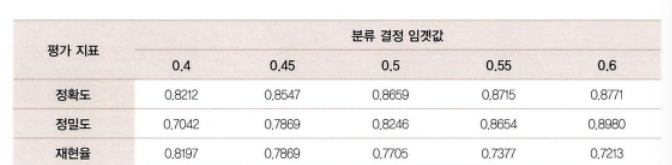

In [32]:
import numpy as np
from sklearn.metrics import precision_recall_curve

# 레이블 값이 1일 때의 예측 확률 추출
pred_proba_class1 = lr_clf.predict_proba(X_test)[:, 1]

# 임계값에 따른 정밀도와 재현율 계산
precisions, recalls, thresholds = precision_recall_curve(
    y_test, pred_proba_class1
)

print('반환된 분류 결정 임계값 배열의 shape:', thresholds.shape)

# 임계값 배열에서 15개 간격으로 샘플 추출
thr_index = np.arange(0, thresholds.shape[0], 15)

print('샘플 추출을 위한 임계값 배열의 index:', thr_index)
print('샘플 임계값:', np.round(thresholds[thr_index], 2))

# 샘플 임계값에 따른 정밀도와 재현율
print('샘플 임계값별 정밀도:', np.round(precisions[thr_index], 3))
print('샘플 임계값별 재현율:', np.round(recalls[thr_index], 3))

반환된 분류 결정 임계값 배열의 shape: (165,)
샘플 추출을 위한 임계값 배열의 index: [  0  15  30  45  60  75  90 105 120 135 150]
샘플 임계값: [0.02 0.11 0.13 0.14 0.16 0.24 0.32 0.45 0.62 0.73 0.87]
샘플 임계값별 정밀도: [0.341 0.372 0.401 0.44  0.505 0.598 0.688 0.774 0.915 0.968 0.938]
샘플 임계값별 재현율: [1.    1.    0.967 0.902 0.902 0.902 0.869 0.787 0.705 0.492 0.246]


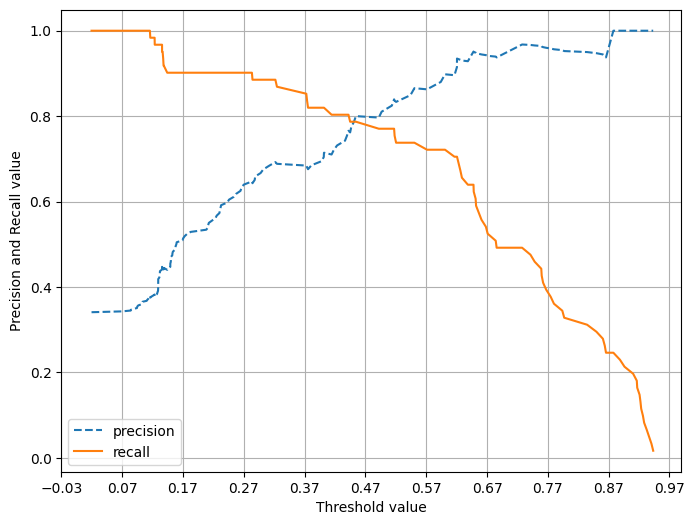

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

%matplotlib inline

def precision_recall_curve_plot(y_test, pred_proba_c1):
    # 임계값에 따른 정밀도와 재현율 추출
    precisions, recalls, thresholds = precision_recall_curve(
        y_test, pred_proba_c1
    )

    # X축: 임계값, Y축: 정밀도와 재현율
    plt.figure(figsize=(8, 6))
    threshold_boundary = thresholds.shape[0]

    plt.plot(
        thresholds,
        precisions[:threshold_boundary],
        linestyle='--',
        label='precision'
    )
    plt.plot(
        thresholds,
        recalls[:threshold_boundary],
        label='recall'
    )

    # X축 눈금을 0.1 간격으로 설정
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1), 2))

    # 축 이름, 범례, 격자 설정
    plt.xlabel('Threshold value')
    plt.ylabel('Precision and Recall value')
    plt.legend()
    plt.grid()
    plt.show()

precision_recall_curve_plot(
    y_test,
    lr_clf.predict_proba(X_test)[:, 1]
)

### 정밀도와 재현율의 맹점

임곗값 변경 : 업무 환경에 맞게 두 개의 수치를 상호 보완할 수 있는 수준에서 적용되어야 함

#### 정밀도 100% 되는 법

확실한 기준만 P로 예측 나머지는 모두 N


#### 재현율 100% 되는 법

모든 환자를 P로 예측하면 됨

➡ 정밀도 또는 재현율 중 하나만 스코어가 좋고 나쁜 부누류는 성능이 좋지 않은 분류로 간주할 수 있음

## F1 스코어


정밀도와 재현율을 결합한 지표

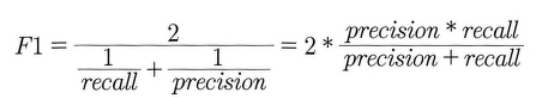

✅사이킷런의 f1_score() API

In [35]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test,pred)
print('F1 스코어:{0:4f}'.format(f1))

F1 스코어:0.796610


In [36]:
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score
)
from sklearn.preprocessing import Binarizer

# F1 스코어를 추가한 평가 함수
def get_clf_eval(y_test, pred):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    print('오차 행렬')
    print(confusion)
    print(
        '정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}, '
        'F1: {3:.4f}'.format(accuracy, precision, recall, f1)
    )

# 임계값별 예측 및 평가
def get_eval_by_threshold(y_test, pred_proba_c1, thresholds):
    for threshold in thresholds:
        binarizer = Binarizer(threshold=threshold)
        custom_predict = binarizer.fit_transform(pred_proba_c1)

        print('\n임계값:', threshold)
        get_clf_eval(y_test, custom_predict.ravel())

thresholds = [0.4, 0.45, 0.50, 0.55, 0.60]
pred_proba = lr_clf.predict_proba(X_test)

get_eval_by_threshold(
    y_test,
    pred_proba[:, 1].reshape(-1, 1),
    thresholds
)


임계값: 0.4
오차 행렬
[[97 21]
 [11 50]]
정확도: 0.8212, 정밀도: 0.7042, 재현율: 0.8197, F1: 0.7576

임계값: 0.45
오차 행렬
[[105  13]
 [ 13  48]]
정확도: 0.8547, 정밀도: 0.7869, 재현율: 0.7869, F1: 0.7869

임계값: 0.5
오차 행렬
[[108  10]
 [ 14  47]]
정확도: 0.8659, 정밀도: 0.8246, 재현율: 0.7705, F1: 0.7966

임계값: 0.55
오차 행렬
[[111   7]
 [ 16  45]]
정확도: 0.8715, 정밀도: 0.8654, 재현율: 0.7377, F1: 0.7965

임계값: 0.6
오차 행렬
[[113   5]
 [ 17  44]]
정확도: 0.8771, 정밀도: 0.8980, 재현율: 0.7213, F1: 0.8000


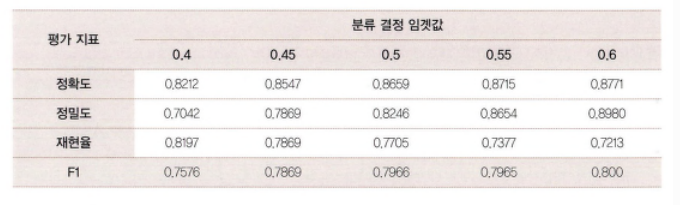

## ROC 곡선과 AUC
✅ ROC 곡선(=수신자 판단 곡선) : FPR이 변할 때 TPR이 어떻게 변하는 지를 나타내는 곡선
- FPR : X축, 1- 특이성
- TPR: 재현율 , Y축 (= 민감도)
- TNR : 특이성
- 가운데 직선에 가까울수록 성능이 떨어짐, 멀어질수록 성능이 뛰어남


▶ FPR 변경
- 분류 결정 임곗값 변경
- FPR 0 -> 임곗값 1
- FPR 1 -> 임곗값 0



In [37]:
import numpy as np
from sklearn.metrics import roc_curve

# 레이블 값이 1일 때의 예측 확률 추출
pred_proba_class1 = lr_clf.predict_proba(X_test)[:, 1]

# 임계값에 따른 FPR, TPR 계산
fprs, tprs, thresholds = roc_curve(y_test, pred_proba_class1)

# 첫 번째 임계값을 제외하고 5개 간격으로 샘플 추출
thr_index = np.arange(1, thresholds.shape[0], 5)

print('샘플 추출을 위한 임계값 배열의 index:', thr_index)
print('샘플 index로 추출한 임계값:', np.round(thresholds[thr_index], 2))

# 샘플 임계값에 따른 FPR, TPR 출력
print('샘플 임계값별 FPR:', np.round(fprs[thr_index], 3))
print('샘플 임계값별 TPR:', np.round(tprs[thr_index], 3))

샘플 추출을 위한 임계값 배열의 index: [ 1  6 11 16 21 26 31 36 41 46]
샘플 index로 추출한 임계값: [0.94 0.73 0.62 0.52 0.44 0.28 0.15 0.14 0.13 0.12]
샘플 임계값별 FPR: [0.    0.008 0.025 0.076 0.127 0.254 0.576 0.61  0.746 0.847]
샘플 임계값별 TPR: [0.016 0.492 0.705 0.738 0.803 0.885 0.902 0.951 0.967 1.   ]


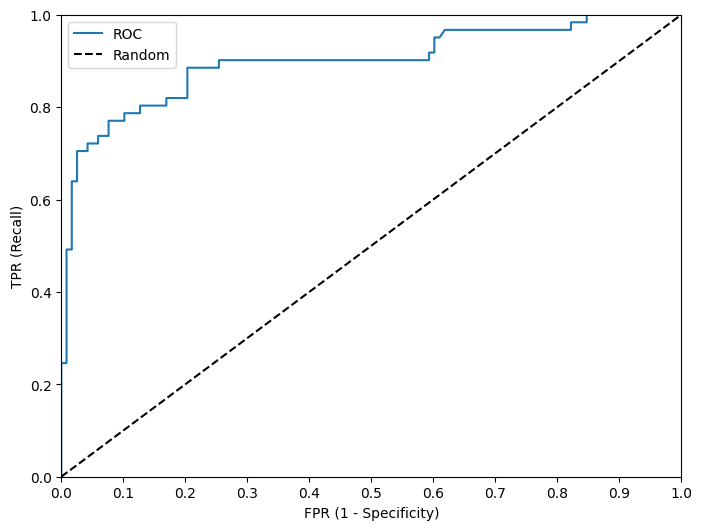

In [38]:
def roc_curve_plot(y_test, pred_proba_c1):
    # 임계값에 따른 FPR, TPR 계산
    fprs, tprs, thresholds = roc_curve(y_test, pred_proba_c1)

    # ROC 곡선과 대각선 그리기
    plt.figure(figsize=(8, 6))
    plt.plot(fprs, tprs, label='ROC')
    plt.plot([0, 1], [0, 1], 'k--', label='Random')

    # 축 범위와 눈금 설정
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xticks(np.round(np.arange(0, 1.1, 0.1), 2))

    plt.xlabel('FPR (1 - Specificity)')
    plt.ylabel('TPR (Recall)')
    plt.legend()
    plt.show()

pred_proba = lr_clf.predict_proba(X_test)
roc_curve_plot(y_test, pred_proba[:, 1])

In [39]:
from sklearn.metrics import roc_auc_score

pred_proba = lr_clf.predict_proba(X_test)[:, 1]
roc_score = roc_auc_score(y_test, pred_proba)
print('ROC AUC 값: {0:.4f}'.format(roc_score))

ROC AUC 값: 0.8987


In [40]:
def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    # ROC-AUC 추가
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    # ROC-AUC print 추가
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}, '
          'F1: {3:.4f}, AUC: {4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

# 피마 인디언 당뇨병 예측
 북아메리카 피마 지역 원주민의 Type-2 당뇨병 결과 데이터
 - 보통 원인으로 식습관과 유전

In [42]:
import pandas as pd

url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'

columns = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
]

diabetes_data = pd.read_csv(url, header=None, names=columns)
diabetes_data.to_csv('/content/diabetes.csv', index=False)

diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.metrics import f1_score, confusion_matrix, precision_recall_curve, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

diabetes_data = pd.read_csv('diabetes.csv')
print(diabetes_data['Outcome'].value_counts())
diabetes_data.head(3)

Outcome
0    500
1    268
Name: count, dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


In [44]:
diabetes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


- 별도의 피처 인코딩 필요 X

▶ 로지스틱 회귀를 이용해 예측 모델 생성

In [45]:
# 피처 데이터 세트 X, 레이블 데이터 세트 y를 추출.
# 맨 끝이 Outcome 칼럼으로 레이블 값임. 칼럼 위치 -1을 이용해 추출
X = diabetes_data.iloc[:, :-1]
y = diabetes_data.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=156, stratify=y
)

# 로지스틱 회귀로 학습, 예측 및 평가 수행.
lr_clf = LogisticRegression(solver='liblinear')
lr_clf.fit(X_train, y_train)
pred = lr_clf.predict(X_test)
pred_proba = lr_clf.predict_proba(X_test)[:, 1]

get_clf_eval(y_test, pred, pred_proba)

오차 행렬
[[87 13]
 [22 32]]
정확도: 0.7727, 정밀도: 0.7111, 재현율: 0.5926, F1: 0.6465, AUC: 0.8083


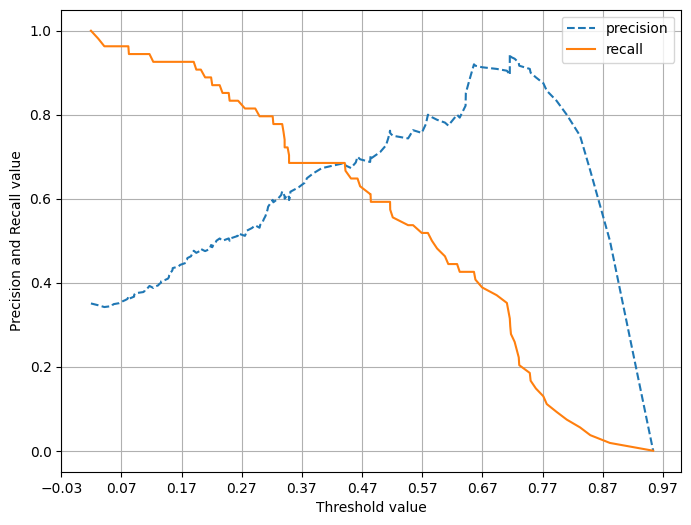

In [46]:
pred_proba_c1 = lr_clf.predict_proba(X_test)[:, 1]
precision_recall_curve_plot(y_test, pred_proba_c1)

In [47]:
diabetes_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


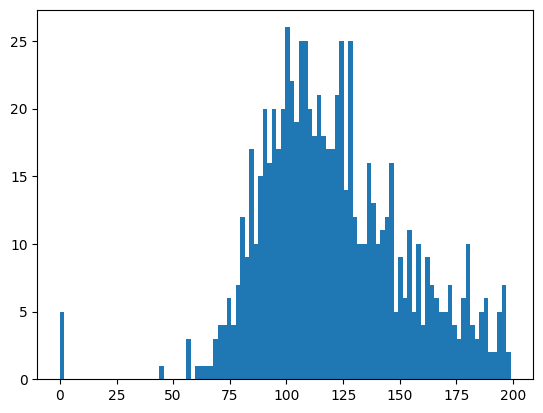

In [48]:
plt.hist(diabetes_data['Glucose'],bins=100)
plt.show()

In [49]:
# 0값을 검사할 피처명 리스트
zero_features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# 전체 데이터 건수
total_count = diabetes_data['Glucose'].count()

# 피처별로 반복하면서 데이터 값이 0인 데이터 건수를 추출하고, 퍼센트 계산
for feature in zero_features:
    zero_count = diabetes_data[diabetes_data[feature] == 0][feature].count()
    print('{0} 0 건수는 {1}, 퍼센트는 {2:.2f} %'.format(
        feature, zero_count, 100 * zero_count / total_count
    ))

Glucose 0 건수는 5, 퍼센트는 0.65 %
BloodPressure 0 건수는 35, 퍼센트는 4.56 %
SkinThickness 0 건수는 227, 퍼센트는 29.56 %
Insulin 0 건수는 374, 퍼센트는 48.70 %
BMI 0 건수는 11, 퍼센트는 1.43 %


In [50]:
# zero_features 리스트 내부에 저장된 개별 피처들에 대해서 0값을 평균 값으로 대체
mean_zero_features = diabetes_data[zero_features].mean()
diabetes_data[zero_features] = diabetes_data[zero_features].replace(0, mean_zero_features)

In [51]:
X = diabetes_data.iloc[:, :-1]
y = diabetes_data.iloc[:, -1]

# StandardScaler 클래스를 이용해 피처 데이터 세트에 일괄적으로 스케일링 적용
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=156, stratify=y
)

# 로지스틱 회귀로 학습, 예측 및 평가 수행.
lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
pred = lr_clf.predict(X_test)
pred_proba = lr_clf.predict_proba(X_test)[:, 1]

get_clf_eval(y_test, pred, pred_proba)

오차 행렬
[[90 10]
 [21 33]]
정확도: 0.7987, 정밀도: 0.7674, 재현율: 0.6111, F1: 0.6804, AUC: 0.8433


In [55]:
thresholds = [0.3, 0.33, 0.36, 0.39, 0.42, 0.45, 0.48, 0.50]
pred_proba = lr_clf.predict_proba(X_test)
get_eval_by_threshold(y_test, pred_proba[:, 1].reshape(-1, 1), thresholds)


임계값: 0.3
오차 행렬
[[67 33]
 [11 43]]
정확도: 0.7143, 정밀도: 0.5658, 재현율: 0.7963, F1: 0.6615, AUC: 0.8433

임계값: 0.33
오차 행렬
[[72 28]
 [12 42]]
정확도: 0.7403, 정밀도: 0.6000, 재현율: 0.7778, F1: 0.6774, AUC: 0.8433

임계값: 0.36
오차 행렬
[[76 24]
 [15 39]]
정확도: 0.7468, 정밀도: 0.6190, 재현율: 0.7222, F1: 0.6667, AUC: 0.8433

임계값: 0.39
오차 행렬
[[78 22]
 [16 38]]
정확도: 0.7532, 정밀도: 0.6333, 재현율: 0.7037, F1: 0.6667, AUC: 0.8433

임계값: 0.42
오차 행렬
[[84 16]
 [18 36]]
정확도: 0.7792, 정밀도: 0.6923, 재현율: 0.6667, F1: 0.6792, AUC: 0.8433

임계값: 0.45
오차 행렬
[[85 15]
 [18 36]]
정확도: 0.7857, 정밀도: 0.7059, 재현율: 0.6667, F1: 0.6857, AUC: 0.8433

임계값: 0.48
오차 행렬
[[88 12]
 [19 35]]
정확도: 0.7987, 정밀도: 0.7447, 재현율: 0.6481, F1: 0.6931, AUC: 0.8433

임계값: 0.5
오차 행렬
[[90 10]
 [21 33]]
정확도: 0.7987, 정밀도: 0.7674, 재현율: 0.6111, F1: 0.6804, AUC: 0.8433


In [53]:
# 임계값을 0.48로 설정한 Binarizer 생성
binarizer = Binarizer(threshold=0.48)

# 위에서 구한 lr_clf의 predict_proba() 예측 확률 array에서
# 1에 해당하는 칼럼값을 Binarizer 변환.
pred_th_048 = binarizer.fit_transform(pred_proba[:, 1].reshape(-1, 1))

get_clf_eval(y_test, pred_th_048, pred_proba[:, 1])

오차 행렬
[[88 12]
 [19 35]]
정확도: 0.7987, 정밀도: 0.7447, 재현율: 0.6481, F1: 0.6931, AUC: 0.8433


## 07 정리

**분류 모델의 성능 평가 지표**

- 주요 평가 지표: 정확도, 오차 행렬, 정밀도, 재현율, F1 스코어, ROC-AUC
- 이진 분류에서 클래스 비율이 불균형하면 정확도만으로 예측 성능을 평가하기 어렵다.

**오차 행렬**

실제 클래스와 예측 클래스를 비교하여 TN, FP, FN, TP로 구분한다.

| 구분 | 실제 클래스 | 예측 클래스 |
|---|---|---|
| TN | Negative | Negative |
| FP | Negative | Positive |
| FN | Positive | Negative |
| TP | Positive | Positive |

- 정확도, 정밀도, 재현율은 TN, FP, FN, TP를 조합하여 계산한다.
- 오차 행렬을 통해 모델이 어떤 유형의 오류를 발생시키는지 파악할 수 있다.

**정밀도와 재현율**

- *정밀도(Precision)*: Positive로 예측한 데이터 중 실제 Positive인 비율
- *재현율(Recall)*: 실제 Positive 데이터 중 Positive로 올바르게 예측한 비율
- 암 진단처럼 실제 Positive를 Negative로 잘못 판단했을 때 영향이 큰 경우에는 재현율이 중요하다.
- 업무 특성에 따라 정밀도 또는 재현율을 강조한다.
- 분류 결정 임계값(Threshold)을 조정하여 정밀도와 재현율을 조절할 수 있다.

**F1 스코어**

- 정밀도와 재현율을 결합한 평가 지표이다.
- 정밀도와 재현율이 어느 한쪽으로 치우치지 않고 모두 높을 때 높은 값을 가진다.

**ROC-AUC**

- 이진 분류의 성능 평가에 널리 사용되는 지표이다.
- AUC(Area Under Curve)는 ROC 곡선 아래의 면적이다.
- 일반적으로 1에 가까울수록 예측 성능이 좋다.

